**Analysis of Bach Two-Part Inventions using Music21**

In [1]:
import warnings
warnings.filterwarnings("ignore")
import music21
import numpy as np
import similaritymeasures
from music21 import converter, analysis, stream
import matplotlib.pyplot as plt
%matplotlib inline

Read a MIDI file and convert to a Music21 Stream*

In [2]:
s = converter.parse('/Users/rowe/Notation/Scores/Bach/BWV772/JSB2PT01.mid')
s

<music21.stream.Score 0x108917b80>

*Count occurrences of pitch classes in stream and plot pc profile*

 0: 0.137931
 1: 0.008621
 2: 0.150862
 3: 0.000000
 4: 0.148707
 5: 0.101293
 6: 0.032328
 7: 0.144397
 8: 0.015086
 9: 0.133621
10: 0.017241
11: 0.109914


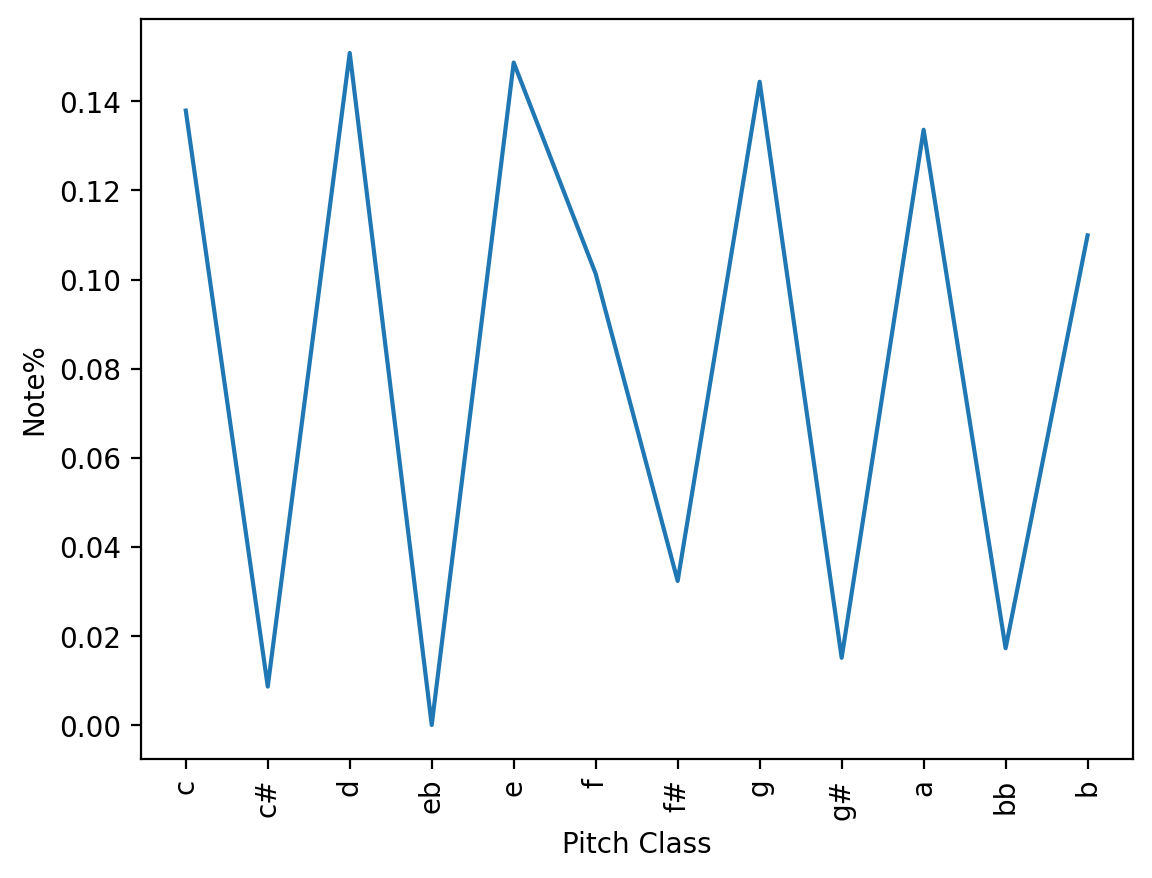

In [4]:
pcCount = analysis.pitchAnalysis.pitchAttributeCount(s, 'pitchClass')
x = []
y = []
notes = 0
pcs = ['c', 'c#', 'd', 'eb', 'e', 'f', 'f#', 'g', 'g#', 'a', 'bb', 'b']
for n in range(12):
    notes = notes + pcCount[n]
for n in range(12):
    x.append(n)
    if (pcCount[n] == 0): 
        y.append(0.0)
    else:
        y.append(pcCount[n]/notes)
    print("%2d: %2f" % (x[n],y[n]))
plt.xlabel('Pitch Class')
plt.xticks(x, pcs, rotation='vertical')
plt.ylabel('Note%')
plt.plot(x, y)
plt.savefig('pc_freq.png', dpi = 300)

*Compute Krumhansl & Kessler tonality profiles*

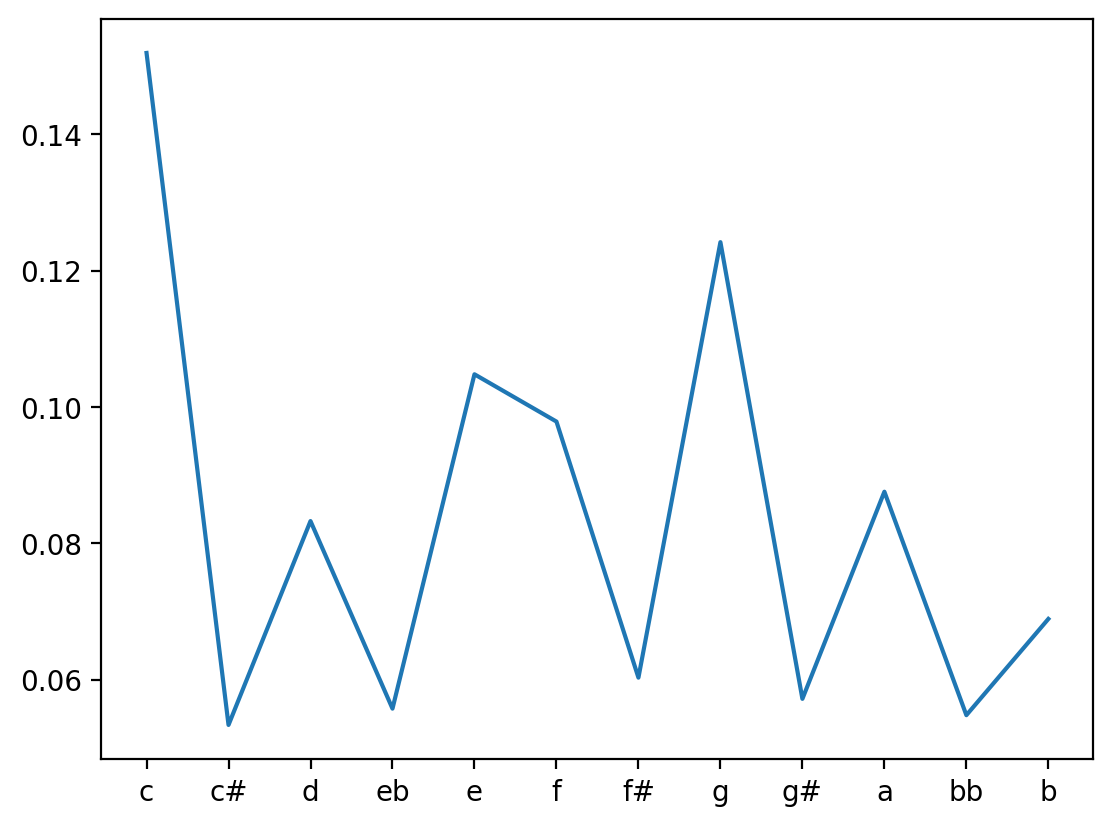

In [5]:
# from Measuring and modeling real-time responses to music: The dynamics of tonality induction (2003)
kkMaj = [6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88]
kkmin = [6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17]
kkMajTotal = 0
kkMinTotal = 0
for n in range(12):
    kkMajTotal = kkMajTotal + kkMaj[n]
    kkMinTotal = kkMinTotal + kkmin[n]
kkMajPct = []
kkMinPct = []
for n in range(12):
    kkMajPct.append(kkMaj[n]/kkMajTotal)
    kkMinPct.append(kkmin[n]/kkMinTotal)
plt.plot(pcs, kkMajPct)
plt.savefig('Cmaj profile.png', dpi = 300)

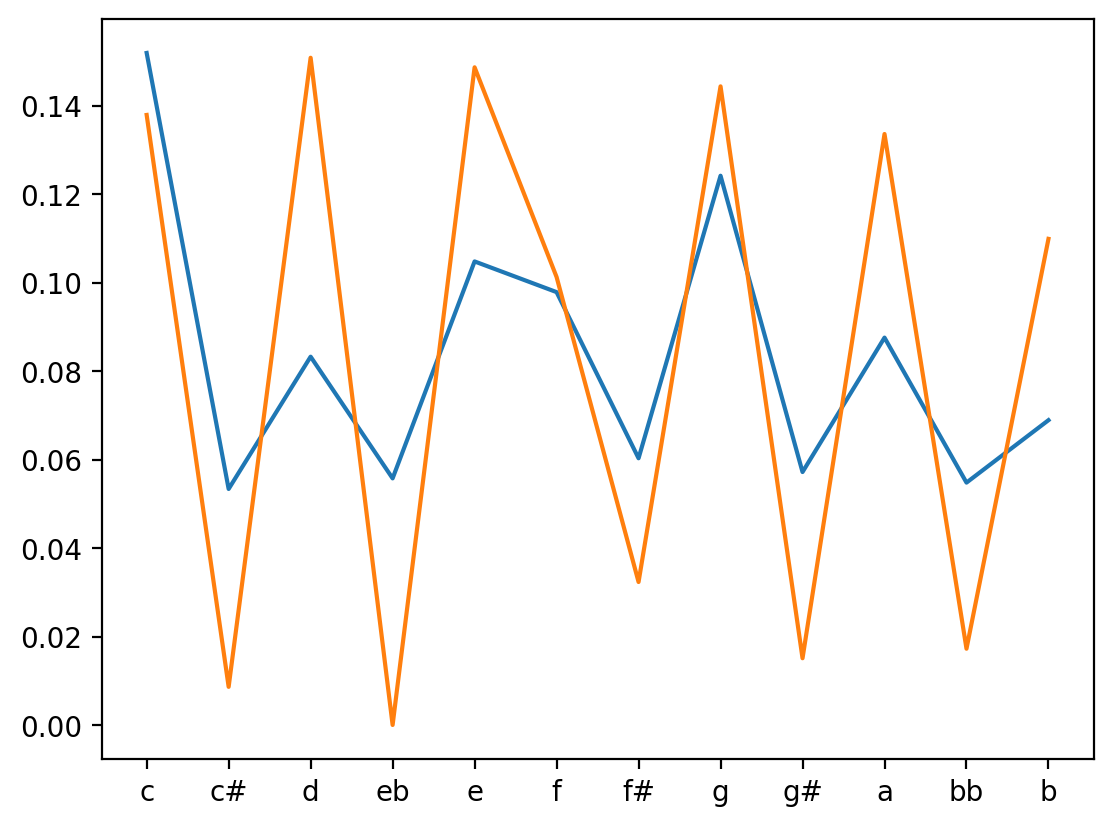

In [6]:
plt.plot(pcs, kkMajPct)
plt.plot(x, y)
plt.savefig('profile comparison.png', dpi = 300)

In [7]:
bach_data1 = np.zeros((12, 2))
bach_data1[:, 0] = x
bach_data1[:, 1] = y
kk_data = np.zeros((12, 2))
kk_data[:, 0] = x
kk_data[:, 1] = kkMajPct
d1diff = []

# quantify the difference between the two curves using Partial Curve Mapping
pcm = similaritymeasures.pcm(bach_data1, kk_data)
d1diff.append(pcm)
print("pcm: %2f" % pcm)

# quantify the difference between the two curves using Discrete Frechet distance
df = similaritymeasures.frechet_dist(bach_data1, kk_data)
d1diff.append(df)
print("df: %2f" % df)

# quantify the difference between the two curves using area between two curves
area = similaritymeasures.area_between_two_curves(bach_data1, kk_data)
d1diff.append(area)
print("area: %2f" % area)

# quantify the difference between the two curves using Curve Length based similarity measure
cl = similaritymeasures.curve_length_measure(bach_data1, kk_data)
d1diff.append(cl)
print("cl: %2f" % cl)

# quantify the difference between the two curves using Dynamic Time Warping distance
dtw, d = similaritymeasures.dtw(bach_data1, kk_data)
d1diff.append(dtw)
print("dtw: %2f" % dtw)

pcm: 2.081916
df: 0.067589
area: 0.416792
cl: 1.790733
dtw: 0.444301


In [8]:
nameCount = analysis.pitchAnalysis.pitchAttributeCount(s, 'name')
for n, count in nameCount.most_common(3):
    print("%2s: %2d" % (n, nameCount[n]))

 D: 70
 E: 69
 G: 67


In [9]:
nameOctaveCount = analysis.pitchAnalysis.pitchAttributeCount(s, 'nameWithOctave')
for n in sorted(nameOctaveCount):
    print("%3s: %2d" % (n, nameOctaveCount[n]))

 A2:  3
 A3: 21
 A4: 28
 A5: 10
B-3:  4
B-4:  4
 B2:  4
 B3: 18
 B4: 26
 B5:  3
C#4:  1
C#5:  3
 C2:  1
 C3:  7
 C4: 24
 C5: 30
 C6:  2
 D2:  1
 D3: 13
 D4: 24
 D5: 32
 E3: 16
 E4: 26
 E5: 27
F#3:  8
F#4:  7
 F3:  6
 F4: 17
 F5: 24
G#3:  2
G#4:  4
G#5:  1
 G2:  4
 G3: 18
 G4: 25
 G5: 20


In [10]:
for el in s.flat.pitches:
    print(el.midi)

60
62
64
65
62
64
60
67
48
50
72
52
53
71
50
52
72
48
55
74
67
43
69
71
72
69
71
67
74
55
57
79
59
60
77
57
59
79
55
60
76
81
59
79
77
60
76
79
62
77
81
64
79
77
55
76
74
57
72
76
59
74
77
60
76
74
52
72
71
54
69
72
55
71
74
57
72
71
59
69
67
60
66
69
67
71
69
60
50
52
62
54
55
72
52
54
50
74
55
71
69
47
67
66
48
64
67
50
66
69
52
67
71
54
69
72
55
71
74
52
72
76
47
74
71
72
74
48
79
50
71
38
69
67
67
43
45
47
48
45
47
43
50
67
55
69
71
54
72
69
55
71
67
57
66
50
52
54
55
52
54
50
57
69
62
71
72
60
74
71
62
72
69
55
71
67
65
64
62
65
64
67
65
74
64
72
71
65
69
72
62
71
74
64
72
69
67
65
64
67
65
69
67
76
65
74
72
67
71
74
64
73
76
65
74
70
69
73
67
65
74
69
67
76
70
69
77
67
65
69
64
62
71
65
64
73
67
65
74
64
62
66
60
59
68
62
60
69
64
62
71
60
59
72
57
56
74
59
57
60
59
74
64
52
66
68
62
69
66
68
64
64
60
76
59
74
57
72
55
76
54
74
57
72
56
71
59
74
57
72
60
81
59
80
62
83
60
81
64
76
62
77
65
74
64
68
77
57
76
74
64
72
52
71
69
57
69
81
45
79
77
76
79
77
81
79
64
62
60
59
62
61
64
6

In [11]:
s2 = converter.parse('/Users/rowe/Notation/Scores/Bach/BWV773/JSB2PT02.mid')
s2

<music21.stream.Score 0x12fa57fd0>

 0: 0.156006
 1: 0.000000
 2: 0.152886
 3: 0.127925
 4: 0.003120
 5: 0.140406
 6: 0.014041
 7: 0.140406
 8: 0.060842
 9: 0.067083
10: 0.115445
11: 0.021841


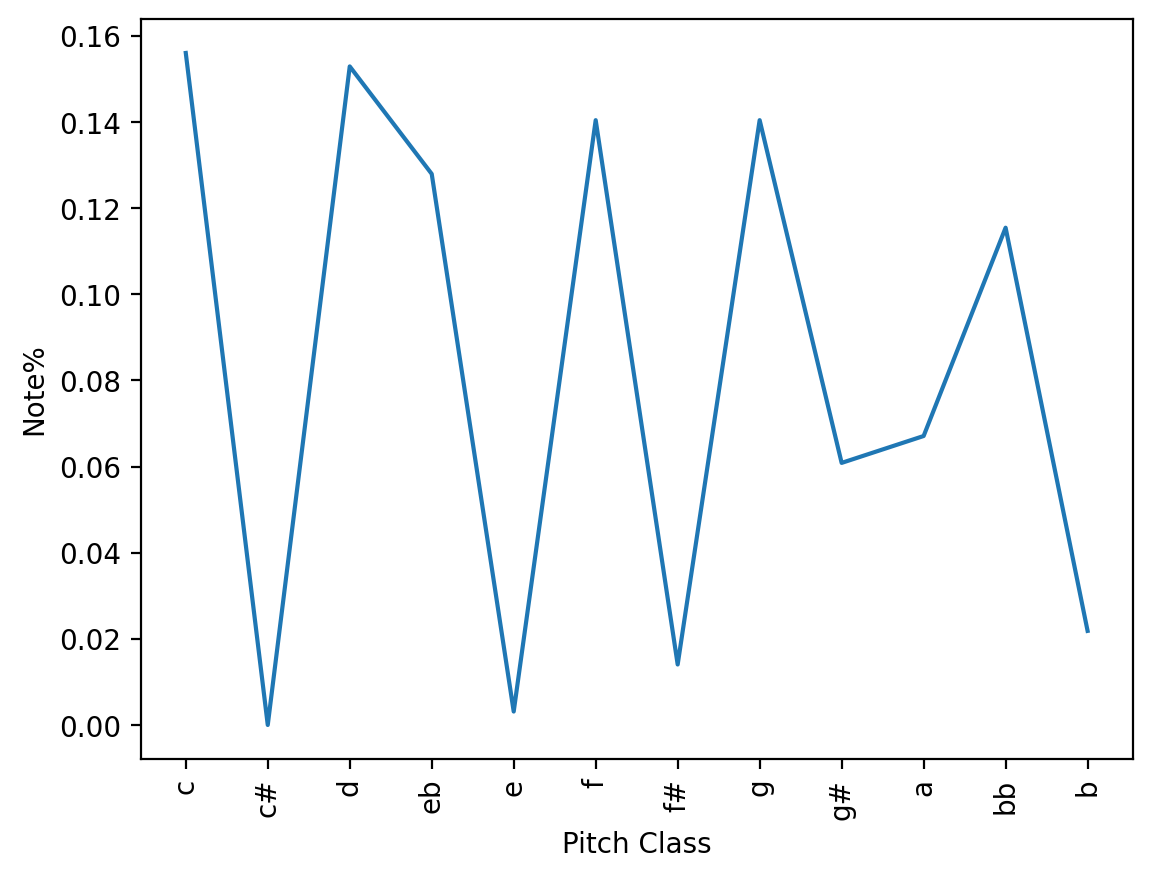

In [12]:
pcCount = analysis.pitchAnalysis.pitchAttributeCount(s2, 'pitchClass')
x = []
y = []
notes = 0
pcs = ['c', 'c#', 'd', 'eb', 'e', 'f', 'f#', 'g', 'g#', 'a', 'bb', 'b']
for n in range(12):
    notes = notes + pcCount[n]
for n in range(12):
    x.append(n)
    if (pcCount[n] == 0): 
        y.append(0.0)
    else:
        y.append(pcCount[n]/notes)
    print("%2d: %2f" % (x[n],y[n]))
plt.xlabel('Pitch Class')
plt.xticks(x, pcs, rotation='vertical')
plt.ylabel('Note%')
plt.plot(x, y)

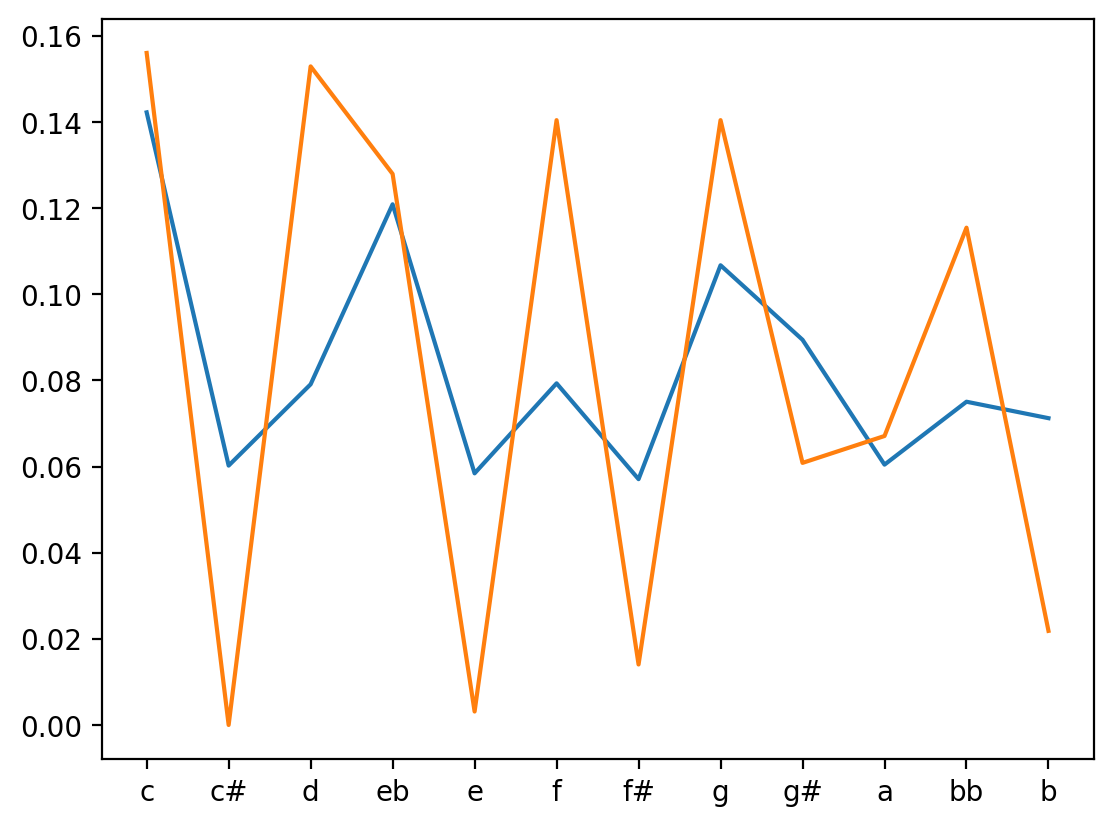

In [13]:
plt.plot(pcs, kkMinPct)
plt.plot(x, y)

In [14]:
bach_data2 = np.zeros((12, 2))
bach_data2[:, 0] = x
bach_data2[:, 1] = y
kk_data = np.zeros((12, 2))
kk_data[:, 0] = x
kk_data[:, 1] = kkMinPct
d2diff = []

# quantify the difference between the two curves using Partial Curve Mapping
pcm = similaritymeasures.pcm(bach_data2, kk_data)
d2diff.append(pcm)
print("pcm: %2f" % pcm)

# quantify the difference between the two curves using Discrete Frechet distance
df = similaritymeasures.frechet_dist(bach_data2, kk_data)
d2diff.append(df)
print("df: %2f" % df)

# quantify the difference between the two curves using area between two curves
area = similaritymeasures.area_between_two_curves(bach_data2, kk_data)
d2diff.append(area)
print("area: %2f" % area)

# quantify the difference between the two curves using Curve Length based similarity measure
cl = similaritymeasures.curve_length_measure(bach_data2, kk_data)
d2diff.append(cl)
print("cl: %2f" % cl)

# quantify the difference between the two curves using Dynamic Time Warping distance
dtw, d = similaritymeasures.dtw(bach_data2, kk_data)
d2diff.append(dtw)
print("dtw: %2f" % dtw)

pcm: 1.799922
df: 0.073803
area: 0.441385
cl: 1.716008
dtw: 0.472970


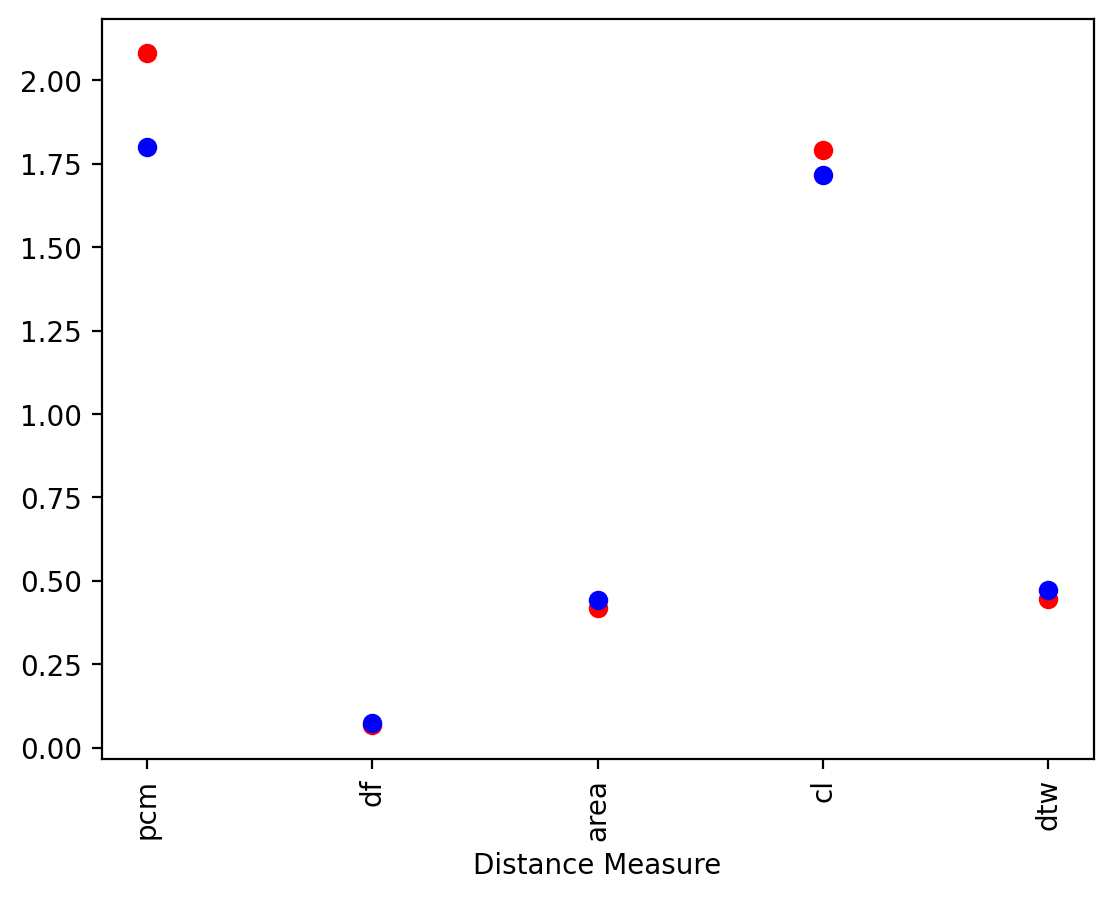

In [15]:
diffs = ['pcm', 'df', 'area', 'cl', 'dtw']
d = []
for n in range(len(diffs)):
    d.append(n)
plt.xlabel('Distance Measure')
plt.xticks(d, diffs, rotation='vertical')
plt.plot(d, d1diff, 'ro')
plt.plot(d, d2diff, 'bo')